Task 4. Noise and Filtering   

Add Gaussian noise (mean=0, sigma=25) to your text-page photo. Before running any filter, jot down a quick prediction: which of Mean/Gaussian/Median/Bilateral do you expect to preserve text edges best, and why? Then run all four and compare against your prediction. If you were off, note what you misunderstood; that's normal and useful for your mentor to see. 

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [39]:
img = cv2.imread("raw_captures\Text.jpeg")
if img is None:
    print("Onnum illa ulla")
else:
    print("Image iruku")

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

Image iruku


In [40]:
mean = 0
sigma = 25
noise = np.random.normal(mean,sigma,img.shape).astype(np.float32)

noisy = img.astype(np.float32)+noise

noisy = np.clip(noisy,0,255).astype(np.uint8)

In [41]:

mean_filter = cv2.blur(noisy,(5,5))

gaussian_filter = cv2.GaussianBlur(noisy,(5,5),0)

median_filter = cv2.medianBlur(noisy,5)

bilateral = cv2.bilateralFilter( noisy, 9, 75,75)

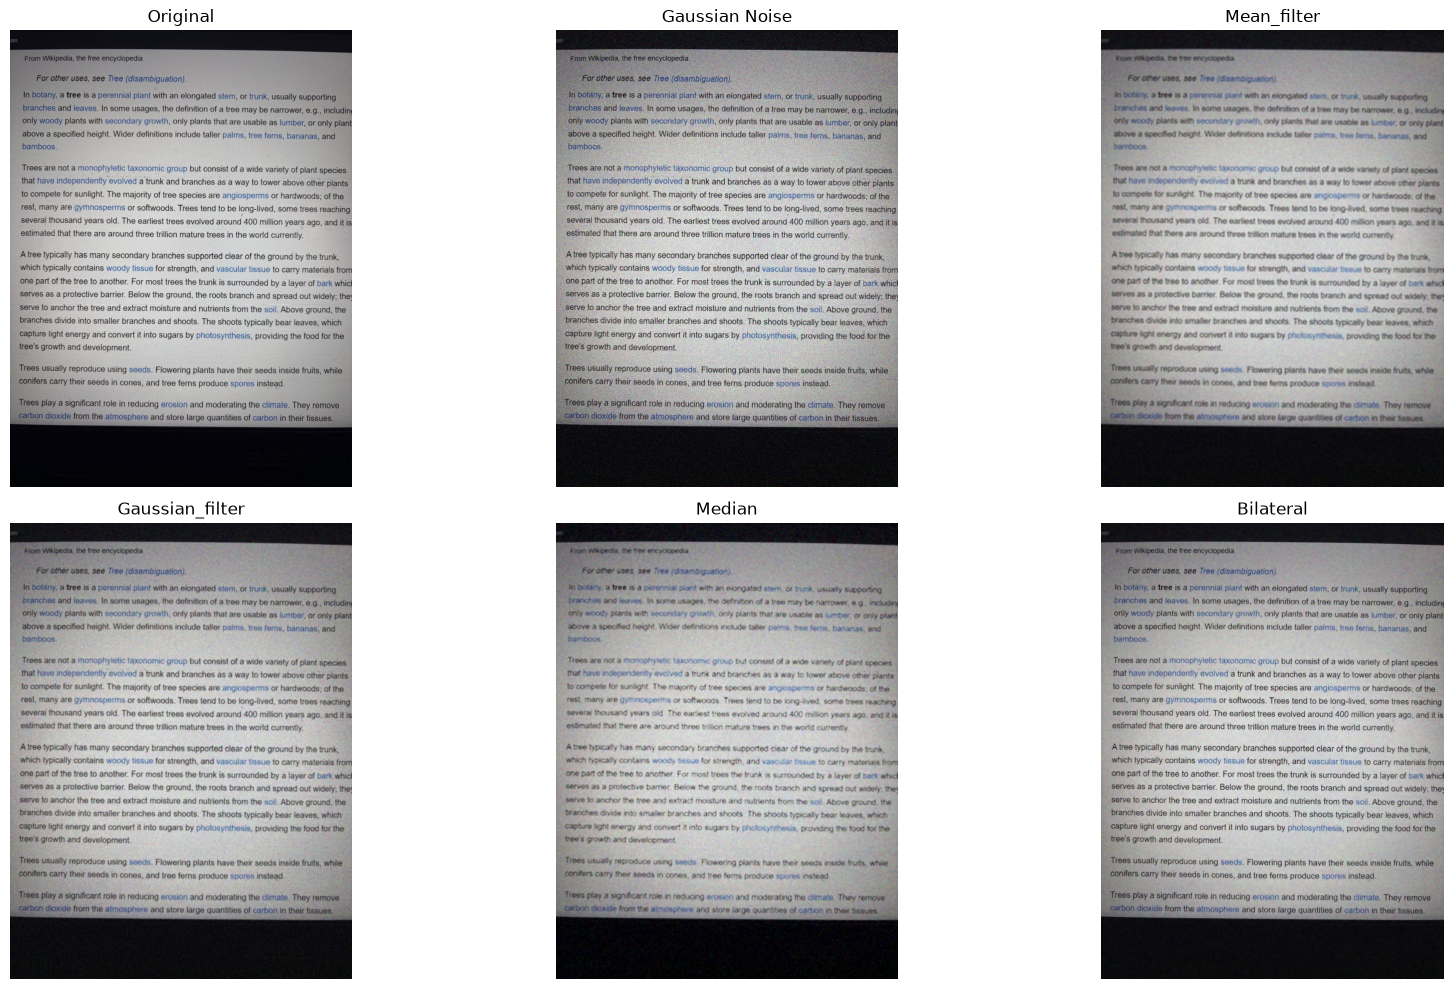

In [42]:
images=[
    ("Original",img),
    ("Gaussian Noise",noisy),
    ("Mean_filter",mean_filter),
    ("Gaussian_filter",gaussian_filter),
    ("Median",median_filter),
    ("Bilateral",bilateral)
]

plt.figure(figsize=(18,10))
for i,(title,image) in enumerate(images):

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()
    

After testing all four filters, the Bilateral Filter produced the sharpest text while reducing most of the Gaussian noise. The Mean and Gaussian filters blurred character boundaries, making the text less sharp. The Median Filter preserved edges reasonably well but was slightly less effective than the Bilateral Filter for this Gaussian-noise example.